# 5 Analysis

Deep-dive analysis and comparison for saved runs.Use `5_local.ipynb` for the minimal pipeline run + quick sanity checks.


**How This Notebook Works**

- **Run selection**: choose Cell/Tune/Model and run stems, then click **Resolve runs**. This loads the single run used by the section buttons below.
- **Section buttons**: each block (cell-only, geometry/synapses, inputs, outputs, comparison) has its own UI controls + button. The plot/output appears directly under that section.
- **Save toggles**: `Save plots` writes images to `output_data/<run>/plots/`; `Save analysis JSON` writes to `output_data/<run>/analysis/`.
- **Load cell for analysis**: when enabled, the notebook loads the NEURON cell (needs compiled mechanisms in the tune) so geometry/mechanism summaries can be computed.
- **Comparison mode**: set `Compare B` to a run (not `none`), then use **Run comparison**. This shows side‑by‑side plots and summary tables.

**If widgets don’t show** (ipywidgets missing), use the manual variables in the top cell and run the numbered sections below.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from IPython.display import display, Markdown
except Exception:
    display = None
    Markdown = None

from modules_local import run_sim, plotting, analysis, bio_curve

def _find_scp_base(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "cells").is_dir() and (p / "run_pipeline.py").is_file():
            return p
        if (p / "single_cells" / "cells").is_dir():
            return p / "single_cells"

    # Shallow search under current dir for a repo that contains the SCP layout
    try:
        for child in start.iterdir():
            if not child.is_dir():
                continue
            if (child / "cells").is_dir() and (child / "run_pipeline.py").is_file():
                return child
            if (child / "single_cells" / "cells").is_dir():
                return child / "single_cells"
    except Exception:
        pass

    return start

BASE_DIR = _find_scp_base(Path.cwd()).resolve()
CELLS_DIR = BASE_DIR / "cells"

# --------------------------
# Defaults (manual mode)
# --------------------------
cell_name = "PV"      # SST, SST_0, PV, PN

tunes_dir = "tunes"
model_dir = "seg_tuned"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison

# --------------------------
# Global toggles
# --------------------------
save_plots = False
save_analysis = False

save_snapshot_compare_table = False
snapshot_compare_scope = "full"  # "snapshot", "meta", or "full"
snapshot_compare_format = "csv"  # "csv", "xlsx", or "both"
snapshot_compare_max_depth = 60
snapshot_compare_max_list_items = 200
plots_dpi = 150

load_cell_for_analysis = True

do_cell_analysis = True
do_geometry_analysis = True
do_synapse_analysis = True
do_input_analysis = True
do_output_analysis = True
do_comparison = True

# Output plots
plot_raster = True
raster_style = "dot"  # "dot" or "line"
plot_window = (None, None)
win_size = 50

# Multi-trial average options (used when results["mode"] == "multi")
multi_plot_type = "line"  # "line", "hist", "both"
multi_shade_mode = None     # None, "sem", "std"
multi_norm_fr = None        # e.g. -4 to normalize to baseline
multi_use_bio_curve = False
bio_curve_path = ""        # CSV path (leave blank to disable)
bio_curve_time_col = "Time"
bio_curve_rate_col = "AvgFiringRate"
bio_curve_time_unit = "s"
bio_curve_t_min = 0.0
bio_curve_delay_ms = 0.0
bio_curve_shift_ms = None   # optional extra shift after load


# Input analysis
plot_inputs_mean = True
plot_input_raster = False
input_raster_style = "dot"
input_raster_trial_idx = 0
input_raster_max_trains = 200
input_raster_win_size = 25.0
input_groups = None
input_bin_ms = None
input_smooth_ms = 50.0
show_input_std = False

# Comparison plots
plot_compare_outputs = True
plot_compare_inputs = True
compare_input_layout = "side-by-side"  # "side-by-side" or "stacked"
compare_tables_diff_only = True
compare_cell_tables = True
compare_geometry_tables = True
compare_synapse_weight_plot = False
compare_synapse_distance_plot = False
compare_synapse_groups = None
compare_synapse_weight_bin = 0.1
compare_synapse_distance_bin = 25.0
compare_synapse_density = True
compare_tables_diff_only = True
compare_cell_tables = True
compare_geometry_tables = True

# --------------------------
# Widgets (optional)
# --------------------------
use_widgets = True
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


cell = None
geom = None
geom_cfg = None
sel = None
base = None
run_single = None
res_single = None


def _list_cells():
    root = CELLS_DIR
    if not root.is_dir():
        return []
    return sorted([p.name for p in root.iterdir() if p.is_dir()])


def _list_tunes(cell: str):
    base = CELLS_DIR / cell
    if not base.is_dir():
        return []
    if (base / "tunes").is_dir():
        return ["tunes"]
    return sorted([p.name for p in base.iterdir() if p.is_dir()])


def _list_models(cell: str, tunes: str):
    base = CELLS_DIR / cell / tunes
    if not base.is_dir():
        return []
    return sorted([p.name for p in base.iterdir() if p.is_dir()])


def _resolve_run_dir(candidate: Path) -> Path:
    if (candidate / "run_manifest.json").is_file():
        return candidate
    nested = candidate / "results"
    if (nested / "run_manifest.json").is_file():
        return nested
    return candidate


def _collect_run_dirs(base_dir: Path):
    candidates = []
    seen = set()
    if not base_dir.is_dir():
        return candidates
    for p in base_dir.iterdir():
        if not p.is_dir():
            continue
        resolved = _resolve_run_dir(p)
        manifest = resolved / "run_manifest.json"
        if manifest.is_file():
            key = str(resolved)
            if key not in seen:
                seen.add(key)
                candidates.append(resolved)
    return sorted(candidates, key=lambda p: (p / "run_manifest.json").stat().st_mtime)


def _resolve_run(base_dir: Path, stem_or_path: str) -> Path:
    p = stem_or_path if isinstance(stem_or_path, Path) else Path(stem_or_path)
    if p.is_absolute():
        return _resolve_run_dir(p)
    runs = _collect_run_dirs(base_dir)
    if stem_or_path in (None, "latest"):
        if not runs:
            raise FileNotFoundError(f"No run folders found under {base_dir}")
        return runs[-1]
    if stem_or_path in ("previous", "prev", "latest-1"):
        if len(runs) < 2:
            raise FileNotFoundError(f"Need at least 2 runs under {base_dir}")
        return runs[-2]
    try:
        parts = list(p.parts)
        if "output_data" in parts:
            idx = parts.index("output_data")
            if idx + 1 < len(parts):
                candidate = base_dir / parts[idx + 1]
                if candidate.exists():
                    return _resolve_run_dir(candidate)
    except Exception:
        pass
    if p.exists():
        return _resolve_run_dir(p)
    candidate = base_dir / stem_or_path
    if candidate.exists():
        return _resolve_run_dir(candidate)
    names = [p.name for p in runs]
    raise FileNotFoundError(f"Run not found: {stem_or_path!r}. Available under {base_dir}: {names}")


def _run_label(run_dir: Path) -> str:
    if run_dir.name == "results":
        return run_dir.parent.name
    return run_dir.name


def _plot_dir_for_run(run_dir: Path) -> Path:
    if run_dir.name == "results":
        return run_dir.parent / "plots"
    return run_dir / "plots"


def _analysis_dir_for_run(run_dir: Path) -> Path:
    if run_dir.name == "results":
        return run_dir.parent / "analysis"
    return run_dir / "analysis"


def _plot_dir_for_compare(base_dir: Path, run_a: Path, run_b: Path) -> Path:
    label = f"{_run_label(run_a)}_vs_{_run_label(run_b)}"
    return base_dir / "_comparisons" / label / "plots"


def _analysis_dir_for_compare(base_dir: Path, run_a: Path, run_b: Path) -> Path:
    label = f"{_run_label(run_a)}_vs_{_run_label(run_b)}"
    return base_dir / "_comparisons" / label / "analysis"


def _ensure_fig(obj=None):
    if obj is None:
        return plt.gcf()
    if isinstance(obj, tuple):
        return obj[0]
    if hasattr(obj, "savefig"):
        return obj
    if hasattr(obj, "figure"):
        return obj.figure
    return plt.gcf()


def _maybe_save(fig, out_path: Path):
    if not save_plots:
        return
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig = _ensure_fig(fig)
    fig.savefig(out_path, dpi=plots_dpi)
    print(f"Saved plot: {out_path}")


def _maybe_save_json(data: dict, out_path: Path):
    if not save_analysis:
        return
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(data, indent=2))
    print(f"Saved analysis: {out_path}")


def _show_md(text: str):
    if display is not None and Markdown is not None:
        display(Markdown(text))
    else:
        print(text)


def _format_diff_list_table(diffs, *, title, max_items=20):
    lines = [f"**{title}**", "| # | Difference |", "| --- | --- |"]
    if not diffs:
        lines.append("| (no differences found) | — |")
        return "\n".join(lines)
    for i, line in enumerate(diffs[:max_items], 1):
        lines.append(f"| {i} | {line} |")
    return "\n".join(lines)

def _snapshot_report_for_runs(base_dir, run_a, run_b, *, res_a=None, res_b=None, labels=None, max_diffs=200, save_table=None, table_scope=None, table_format=None, table_max_depth=None, table_max_list_items=None):
    label_a = labels[0] if labels else _run_label(run_a)
    label_b = labels[1] if labels else _run_label(run_b)
    save_table = save_snapshot_compare_table if save_table is None else save_table
    table_scope = snapshot_compare_scope if table_scope is None else table_scope
    table_format = snapshot_compare_format if table_format is None else table_format
    table_max_depth = snapshot_compare_max_depth if table_max_depth is None else table_max_depth
    table_max_list_items = snapshot_compare_max_list_items if table_max_list_items is None else table_max_list_items
    report = analysis.compare_snapshot_runs(
        res_a or run_a,
        res_b or run_b,
        labels=(label_a, label_b),
        max_diffs=max_diffs,
        rtol=0.0,
        atol=0.0,
        print_summary=False,
    )
    print(f"Snapshot compare: equal={report['equal']}, n_diffs={report['n_diffs']}")
    _show_md(report["snapshot_diff_table"])
    if not compare_tables_diff_only:
        _show_md(
            analysis.format_snapshot_compare(
                report["snapshot_a"],
                report["snapshot_b"],
                labels=(label_a, label_b),
            )
        )
    if report.get("manifest_diff"):
        _show_md(
            _format_diff_list_table(
                report["manifest_diff"],
                title="Manifest differences",
                max_items=40,
            )
        )
    if report.get("diffs"):
        _show_md(
            _format_diff_list_table(
                report["diffs"],
                title="Deep differences (first 20)",
                max_items=20,
            )
        )
    if save_table:
        out_dir = _analysis_dir_for_compare(base_dir, run_a, run_b)
        compare_path = out_dir / f"snapshot_compare_{table_scope}"
        analysis.save_compare_table(
            res_a or run_a,
            res_b or run_b,
            compare_path,
            scope=table_scope,
            fmt=table_format,
            max_depth=table_max_depth,
            max_list_items=table_max_list_items,
        )
        print(f"Saved snapshot compare table to {compare_path} ({table_format})")

    if save_analysis:
        out_dir = _analysis_dir_for_compare(base_dir, run_a, run_b)
        _maybe_save_json(report, out_dir / "snapshot_compare.json")
    return report


def run_snapshot_compare(save_table=None, table_scope=None, table_format=None, table_max_depth=None, table_max_list_items=None):
    sel_local = _get_selection()
    if sel_local["run_b"] in (None, "none", "", "None"):
        print("Snapshot compare disabled (set Compare B to a run name).")
        return None
    run_a = _resolve_run(sel_local["base"], sel_local["run_a"])
    run_b = _resolve_run(sel_local["base"], sel_local["run_b"])
    res_a = run_sim.load_results(run_a)
    res_b = run_sim.load_results(run_b)
    label_a = _run_label(run_a)
    label_b = _run_label(run_b)
    return _snapshot_report_for_runs(
        sel_local["base"],
        run_a,
        run_b,
        res_a=res_a,
        res_b=res_b,
        labels=(label_a, label_b),
        save_table=save_table,
        table_scope=table_scope,
        table_format=table_format,
        table_max_depth=table_max_depth,
        table_max_list_items=table_max_list_items,
    )

def _safe_results(res: dict) -> dict:
    out = dict(res)
    spikes = out.get("spikes")
    if isinstance(spikes, np.ndarray):
        out["spikes"] = spikes.tolist()
    return out


def _parse_groups(text: str):
    if text is None:
        return None
    text = text.strip()
    if not text:
        return None
    return [p.strip() for p in text.split(",") if p.strip()]


def _parse_optional_float(text: str):
    if text is None:
        return None
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(text)
    except ValueError:
        return None




def _load_bio_curve():
    if not multi_use_bio_curve:
        return None
    if not bio_curve_path:
        print("Bio curve enabled but bio_curve_path is empty.")
        return None
    try:
        t_s, rate = bio_curve.load_bio_curve(
            bio_curve_path,
            time_col=bio_curve_time_col,
            rate_col=bio_curve_rate_col,
            t_min=bio_curve_t_min,
            delay_ms=bio_curve_delay_ms,
            time_unit=bio_curve_time_unit,
        )
    except Exception as exc:
        print("Bio curve load failed:", exc)
        return None
    if bio_curve_shift_ms is not None:
        t_s = t_s + float(bio_curve_shift_ms) / 1000.0
    return (t_s, rate)


def _syn_values(syn_records, field, groups=None):
    if not syn_records:
        return np.array([], dtype=float)
    if groups is None or groups == ["all"]:
        groups = list(syn_records.keys())
    vals = []
    for g in groups:
        for rec in syn_records.get(g, []) or []:
            if isinstance(rec, dict):
                val = rec.get(field)
            else:
                val = getattr(rec, field, None)
            if val is not None:
                vals.append(float(val))
    return np.asarray(vals, dtype=float)


def _plot_syn_compare(vals_a, vals_b, *, bin_width, labels, xlabel, title, density=True):
    if vals_a.size == 0 and vals_b.size == 0:
        print(f"No synapse data for {title}.")
        return None
    all_vals = np.concatenate([v for v in (vals_a, vals_b) if v.size])
    if all_vals.size == 0:
        print(f"No synapse data for {title}.")
        return None
    lo, hi = float(all_vals.min()), float(all_vals.max())
    if lo == hi:
        lo -= 0.5 * bin_width
        hi += 0.5 * bin_width
    edges = np.arange(lo, hi + bin_width, bin_width, dtype=float)
    centers = (edges[:-1] + edges[1:]) * 0.5

    plt.figure(figsize=(6, 4))
    if vals_a.size:
        y_a, _ = np.histogram(vals_a, bins=edges, density=density)
        plt.plot(centers, y_a, lw=2, label=labels[0])
    if vals_b.size:
        y_b, _ = np.histogram(vals_b, bins=edges, density=density)
        plt.plot(centers, y_b, lw=2, label=labels[1])

    plt.xlabel(xlabel)
    plt.ylabel("Density" if density else "Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    return plt.gcf()

def _get_selection():
    if use_widgets and _HAVE_WIDGETS:
        cell = cell_dd.value
        tunes = tunes_dd.value
        model = model_dd.value
        run_single = run_single_dd.value
        run_a = run_a_dd.value
        run_b = run_b_dd.value
    else:
        cell = cell_name
        tunes = tunes_dir
        model = model_dir
        run_single = run_single_stem
        run_a = run_compare_a
        run_b = run_compare_b
    base_dir = CELLS_DIR / cell / tunes / model / "output_data"
    return {
        "cell": cell,
        "tunes": tunes,
        "model": model,
        "base": base_dir,
        "run_single": run_single,
        "run_a": run_a,
        "run_b": run_b,
    }


def resolve_runs():
    global sel, base, run_single, res_single
    sel = _get_selection()
    base = sel["base"]
    run_single = _resolve_run(base, sel["run_single"])
    res_single = run_sim.load_results(run_single)
    print("Base:", base)
    print("Resolved single run:", run_single)
    print("Mode:", res_single.get("mode"))
    print("Trials:", (res_single.get("meta") or {}).get("n_trials"))
    return res_single


def _ensure_single_loaded():
    if res_single is None:
        resolve_runs()


def _ensure_cell_geom():
    global cell, geom, geom_cfg, sel
    if cell is not None and geom is not None:
        return
    if not load_cell_for_analysis:
        return
    if sel is None:
        sel = _get_selection()
    tune_dir = (CELLS_DIR / sel['cell'] / sel['tunes'] / sel['model']).resolve()
    cell_cfg_path = tune_dir / "cell_configs" / "cell_config.json"
    geom_cfg_path = tune_dir / "cell_configs" / "geometry.json"

    try:
        cell_cfg = json.loads(cell_cfg_path.read_text())
        manifest = cell_cfg.get("paths", {}).get("manifest", "manifest.json")
        manifest_path = Path(manifest)
        if not manifest_path.is_absolute():
            manifest_path = (tune_dir / manifest).resolve()
        if not manifest_path.is_file():
            fallback = (tune_dir / "manifest.json").resolve()
            if fallback.is_file():
                manifest_path = fallback
            else:
                raise FileNotFoundError(
                    f"manifest.json not found. Tried {manifest_path} and {fallback} (tune_dir={tune_dir})"
                )
        cell_cfg.setdefault("paths", {})["manifest"] = str(manifest_path)
        if geom_cfg_path.is_file():
            geom_cfg = json.loads(geom_cfg_path.read_text())

        from modules_local import load_cell, geometry as geom_mod

        cwd = Path.cwd()
        try:
            os.chdir(tune_dir)
            cell = load_cell(cell_cfg)
            geom = geom_mod.define_geometry(cell, geom_cfg)
        finally:
            os.chdir(cwd)
    except Exception as exc:
        print("Cell/geometry load failed:", exc)


def run_cell_only_analysis():
    if not do_cell_analysis:
        print("Cell-only analysis disabled.")
        return
    _ensure_single_loaded()
    if not load_cell_for_analysis:
        print("Cell loading disabled; enable load_cell_for_analysis to run this section.")
        return
    _ensure_cell_geom()
    if cell is None:
        return
    cell_sections = analysis.summarize_cell_sections(cell)
    mech_summary = analysis.summarize_mechanisms(cell)
    _show_md(analysis.format_section_summary_table(cell_sections, title=f"{_run_label(run_single)} cell sections"))
    print()
    _show_md(analysis.format_mechanism_summary_table(mech_summary, title="Mechanisms (per section group)"))
    _maybe_save_json(cell_sections, _analysis_dir_for_run(run_single) / "cell_sections.json")
    _maybe_save_json(mech_summary, _analysis_dir_for_run(run_single) / "cell_mechanisms.json")


def run_geometry_synapse_analysis():
    _ensure_single_loaded()
    if do_geometry_analysis:
        if load_cell_for_analysis:
            _ensure_cell_geom()
        if geom is not None:
            geom_summary = analysis.summarize_geometry(geom, geom_config=geom_cfg)
            _show_md(analysis.format_geometry_summary_table(geom_summary, title="Geometry distances"))
            _maybe_save_json(geom_summary, _analysis_dir_for_run(run_single) / "geometry_summary.json")
            print()
        else:
            print("Geometry analysis skipped (no geometry loaded).")
    if do_synapse_analysis:
        syn_summary = analysis.summarize_synapse_records(
            res_single.get("syn_records") or {},
            geom=geom,
            duration_ms=analysis._get_duration_ms(res_single),
        )
        if syn_summary.get("groups"):
            _show_md(analysis.format_synapse_summary_table(syn_summary, title="Synapse placement + weights"))
            _maybe_save_json(syn_summary, _analysis_dir_for_run(run_single) / "synapse_summary.json")
        else:
            print("No synapse records found for this run.")


def run_input_analysis():
    if not do_input_analysis:
        print("Input analysis disabled.")
        return
    _ensure_single_loaded()
    if plot_inputs_mean:
        summary_single = analysis.summarize_inputs_from_results(
            res_single,
            groups=input_groups,
            bin_ms=input_bin_ms,
            smooth_ms=input_smooth_ms,
        )
        curve_single = (res_single.get("meta") or {}).get("avg_rate_curve")
        fig_in, _ = plotting.plot_input_means(
            summary_single,
            label=_run_label(run_single),
            groups=input_groups,
            show_std=show_input_std,
            output_curve=curve_single,
        )
        _maybe_save(fig_in, _plot_dir_for_run(run_single) / "inputs_mean.png")
        _maybe_save_json(summary_single, _analysis_dir_for_run(run_single) / "inputs_summary.json")

    if plot_input_raster:
        inputs_payload = res_single.get("inputs")
        if inputs_payload is None and res_single.get("inputs_by_trial"):
            trials = res_single.get("inputs_by_trial") or []
            if trials:
                idx = min(max(int(input_raster_trial_idx), 0), len(trials) - 1)
                inputs_payload = (trials[idx] or {}).get("inputs")
        if inputs_payload:
            plotting.plot_inputs_by_group(
                inputs_payload,
                res_single.get("sim_cfg", {}) or {},
                groups=input_groups,
                bin_ms=input_bin_ms,
                win_size=input_raster_win_size,
                raster_style=input_raster_style,
                max_trains_per_group=input_raster_max_trains,
                plot_window=plot_window,
                plot_raster=True,
            )
            _maybe_save(plt.gcf(), _plot_dir_for_run(run_single) / "inputs_raster.png")
        else:
            print("No saved inputs available for raster plot.")


def run_output_analysis():
    if not do_output_analysis:
        print("Output analysis disabled.")
        return
    _ensure_single_loaded()
    in_vivo_curve = _load_bio_curve()
    mode = (res_single or {}).get("mode", "single")
    if mode == "multi":
        spikes_by_trial = res_single.get("spikes", []) or []
        if isinstance(spikes_by_trial, np.ndarray):
            spikes_by_trial = spikes_by_trial.tolist()
        all_param_data = {"multi": spikes_by_trial}
        sim_cfg = res_single.get("sim_cfg", {}) or {}
        sim_params = {
            "tstop": float(sim_cfg.get("tstop", 0.0)),
            "bins": float(sim_cfg.get("bins", 25.0)),
            "delay": float(sim_cfg.get("delay", 0.0)),
            "n_trials": len(spikes_by_trial),
            "color": sim_cfg.get("color", None),
            "stim_start_ms": sim_cfg.get("stim_start_ms"),
            "stim_stop_ms": sim_cfg.get("stim_stop_ms"),
            "stim_duration_ms": sim_cfg.get("stim_duration_ms"),
        }
        pw = plot_window
        if pw is not None and not isinstance(pw, dict):
            pw = {"x": (pw[0], pw[1]), "y": (None, None)}
        plot_bio = None
        if in_vivo_curve is not None:
            try:
                t_s, rate = in_vivo_curve
                plot_bio = (True, np.asarray(t_s), np.asarray(rate))
            except Exception:
                plot_bio = None
        plotting.plot_multi(
            all_param_data,
            sim_params=sim_params,
            win_size=win_size,
            plot_type=multi_plot_type,
            plot_bio=plot_bio,
            plot_raster=plot_raster,
            raster_style=raster_style,
            plot_window=pw,
            norm_fr=multi_norm_fr,
            shade_mode=multi_shade_mode,
            set_color=sim_cfg.get("color", None),
        )
        _maybe_save(plt.gcf(), _plot_dir_for_run(run_single) / "output_plot.png")
    else:
        fig_out = plotting.plot_results(
            res_single,
            syn_records=res_single.get("syn_records"),
            in_vivo_curve=in_vivo_curve,
            win_size=win_size,
            raster_style=raster_style,
            plot_raster=plot_raster,
            plot_window=plot_window,
        )
        _maybe_save(fig_out, _plot_dir_for_run(run_single) / "output_plot.png")

    stats_single = analysis.summarize_spike_trials(res_single, plot=True)
    _maybe_save(plt.gcf(), _plot_dir_for_run(run_single) / "spike_stats.png")
    _maybe_save_json(stats_single, _analysis_dir_for_run(run_single) / "spike_stats.json")


def run_comparison_analysis():
    if not do_comparison:
        print("Comparison disabled.")
        return
    sel_local = _get_selection()
    if sel_local["run_b"] in (None, "none", "", "None"):
        print("Comparison disabled (set Compare B to a run name).")
        return

    run_a = _resolve_run(sel_local["base"], sel_local["run_a"])
    run_b = _resolve_run(sel_local["base"], sel_local["run_b"])
    res_a = run_sim.load_results(run_a)
    res_b = run_sim.load_results(run_b)

    label_a = _run_label(run_a)
    label_b = _run_label(run_b)

    print("Compare:", label_a, "vs", label_b)

    snapshot_report = _snapshot_report_for_runs(
        sel_local["base"],
        run_a,
        run_b,
        res_a=res_a,
        res_b=res_b,
        labels=(label_a, label_b),
    )

    if compare_cell_tables or compare_geometry_tables:
        if not load_cell_for_analysis:
            print("Cell/geometry comparison skipped (load_cell_for_analysis is False).")
        else:
            _ensure_cell_geom()
            if cell is None:
                print("Cell/geometry comparison skipped (cell load failed).")
            else:
                if compare_cell_tables:
                    cell_sections = analysis.summarize_cell_sections(cell)
                    mech_summary = analysis.summarize_mechanisms(cell)
                    _show_md(
                        analysis.format_section_summary_compare(
                            cell_sections,
                            cell_sections,
                            labels=(label_a, label_b),
                            diff_only=compare_tables_diff_only,
                            title="Cell sections",
                        )
                    )
                    _show_md(
                        analysis.format_mechanism_summary_compare(
                            mech_summary,
                            mech_summary,
                            labels=(label_a, label_b),
                            diff_only=compare_tables_diff_only,
                            title="Mechanisms",
                        )
                    )
                    _maybe_save_json(
                        cell_sections,
                        _analysis_dir_for_compare(sel_local["base"], run_a, run_b) / "cell_sections_shared.json",
                    )
                    _maybe_save_json(
                        mech_summary,
                        _analysis_dir_for_compare(sel_local["base"], run_a, run_b) / "cell_mechanisms_shared.json",
                    )
                if compare_geometry_tables:
                    if geom is not None:
                        geom_summary = analysis.summarize_geometry(geom, geom_config=geom_cfg)
                        _show_md(
                            analysis.format_geometry_summary_compare(
                                geom_summary,
                                geom_summary,
                                labels=(label_a, label_b),
                                diff_only=compare_tables_diff_only,
                                title="Geometry distances",
                            )
                        )
                        _maybe_save_json(
                            geom_summary,
                            _analysis_dir_for_compare(sel_local["base"], run_a, run_b) / "geometry_summary_shared.json",
                        )
                    else:
                        print("Geometry comparison skipped (no geometry loaded).")

    if plot_compare_outputs:
        try:
            fig_cmp, _ = plotting.plot_compare_side_by_side(
                _safe_results(res_a),
                _safe_results(res_b),
                labels=(label_a, label_b),
                win_size=win_size,
                plot_window=plot_window,
            )
            _maybe_save(fig_cmp, _plot_dir_for_compare(sel_local["base"], run_a, run_b) / "compare_outputs.png")
        except Exception as exc:
            print("Output compare plot failed:", exc)

    if plot_compare_inputs:
        summary_a = analysis.summarize_inputs_from_results(res_a, groups=input_groups, bin_ms=input_bin_ms)
        summary_b = analysis.summarize_inputs_from_results(res_b, groups=input_groups, bin_ms=input_bin_ms)
        fig_cmp_in, _ = plotting.plot_compare_input_means(
            summary_a,
            summary_b,
            labels=(label_a, label_b),
            groups=input_groups,
            layout=compare_input_layout,
            show_std=show_input_std,
            output_curves=(
                (res_a.get("meta") or {}).get("avg_rate_curve"),
                (res_b.get("meta") or {}).get("avg_rate_curve"),
            ),
        )
        _maybe_save(fig_cmp_in, _plot_dir_for_compare(sel_local["base"], run_a, run_b) / "compare_inputs.png")

    _ensure_cell_geom()
    syn_summary_a = analysis.summarize_synapse_records(
        res_a.get("syn_records") or {},
        geom=geom,
        duration_ms=analysis._get_duration_ms(res_a),
    )
    syn_summary_b = analysis.summarize_synapse_records(
        res_b.get("syn_records") or {},
        geom=geom,
        duration_ms=analysis._get_duration_ms(res_b),
    )

    if compare_synapse_weight_plot or compare_synapse_distance_plot:
        syn_groups = compare_synapse_groups
        vals_w_a = _syn_values(res_a.get("syn_records") or {}, "weight", syn_groups)
        vals_w_b = _syn_values(res_b.get("syn_records") or {}, "weight", syn_groups)
        vals_d_a = _syn_values(res_a.get("syn_records") or {}, "distance", syn_groups)
        vals_d_b = _syn_values(res_b.get("syn_records") or {}, "distance", syn_groups)

        if compare_synapse_weight_plot:
            fig_w = _plot_syn_compare(
                vals_w_a,
                vals_w_b,
                bin_width=compare_synapse_weight_bin,
                labels=(label_a, label_b),
                xlabel="Synaptic weight",
                title="Synapse weight distribution",
                density=compare_synapse_density,
            )
            if fig_w is not None:
                _maybe_save(fig_w, _plot_dir_for_compare(sel_local["base"], run_a, run_b) / "syn_weight_compare.png")

        if compare_synapse_distance_plot:
            fig_d = _plot_syn_compare(
                vals_d_a,
                vals_d_b,
                bin_width=compare_synapse_distance_bin,
                labels=(label_a, label_b),
                xlabel="Distance from soma (um)",
                title="Synapse distance distribution",
                density=compare_synapse_density,
            )
            if fig_d is not None:
                _maybe_save(fig_d, _plot_dir_for_compare(sel_local["base"], run_a, run_b) / "syn_distance_compare.png")

    if syn_summary_a.get("groups") or syn_summary_b.get("groups"):
        _show_md(
            analysis.format_synapse_summary_compare(
                syn_summary_a,
                syn_summary_b,
                labels=(label_a, label_b),
                diff_only=compare_tables_diff_only,
                title="Synapse summary",
            )
        )

        _maybe_save_json(syn_summary_a, _analysis_dir_for_compare(sel_local["base"], run_a, run_b) / "syn_summary_a.json")
        _maybe_save_json(syn_summary_b, _analysis_dir_for_compare(sel_local["base"], run_a, run_b) / "syn_summary_b.json")


if use_widgets and _HAVE_WIDGETS:
    cells = _list_cells() or [cell_name]
    cell_dd = widgets.Dropdown(options=cells, value=cell_name, description="Cell")

    tunes = _list_tunes(cell_dd.value) or [tunes_dir]
    tunes_dd = widgets.Dropdown(options=tunes, value=tunes_dir, description="Tunes")

    models = _list_models(cell_dd.value, tunes_dd.value) or [model_dir]
    model_dd = widgets.Dropdown(options=models, value=model_dir, description="Model")

    run_single_dd = widgets.Dropdown(options=["latest", "previous"], value=run_single_stem, description="Single")
    run_a_dd = widgets.Dropdown(options=["latest", "previous"], value=run_compare_a, description="Compare A")
    run_b_dd = widgets.Dropdown(options=["none", "latest", "previous"], value=run_compare_b, description="Compare B")

    def _refresh_runs(*_):
        base_dir = CELLS_DIR / cell_dd.value / tunes_dd.value / model_dd.value / "output_data"
        names = [_run_label(p) for p in _collect_run_dirs(base_dir)]
        options = ["latest", "previous"] + names
        run_single_dd.options = options
        run_a_dd.options = options
        run_b_dd.options = ["none"] + options

    def _refresh_models(*_):
        models = _list_models(cell_dd.value, tunes_dd.value) or [model_dir]
        model_dd.options = models
        if model_dd.value not in model_dd.options:
            model_dd.value = model_dd.options[0]
        _refresh_runs()

    cell_dd.observe(_refresh_models, names="value")
    tunes_dd.observe(_refresh_models, names="value")
    model_dd.observe(_refresh_runs, names="value")

    _refresh_runs()

    out_resolve = widgets.Output()
    out_cell = widgets.Output()
    out_geom = widgets.Output()
    out_inputs = widgets.Output()
    out_outputs = widgets.Output()
    out_compare = widgets.Output()

    save_plots_cb = widgets.Checkbox(value=save_plots, description="Save plots")
    save_analysis_cb = widgets.Checkbox(value=save_analysis, description="Save analysis JSON")
    load_cell_cb = widgets.Checkbox(value=load_cell_for_analysis, description="Load cell for analysis")

    def _sync_common():
        global save_plots, save_analysis, load_cell_for_analysis
        save_plots = save_plots_cb.value
        save_analysis = save_analysis_cb.value
        load_cell_for_analysis = load_cell_cb.value

    resolve_btn = widgets.Button(description="Resolve runs")
    def _on_resolve(_):
        _sync_common()
        with out_resolve:
            out_resolve.clear_output()
            resolve_runs()
    resolve_btn.on_click(_on_resolve)

    cell_btn = widgets.Button(description="Run cell-only")
    cell_do_cb = widgets.Checkbox(value=do_cell_analysis, description="Cell analysis")
    def _on_cell(_):
        global do_cell_analysis
        _sync_common()
        do_cell_analysis = cell_do_cb.value
        with out_cell:
            out_cell.clear_output()
            run_cell_only_analysis()
    cell_btn.on_click(_on_cell)

    geom_btn = widgets.Button(description="Run geometry/synapses")
    geom_do_cb = widgets.Checkbox(value=do_geometry_analysis, description="Geometry")
    syn_do_cb = widgets.Checkbox(value=do_synapse_analysis, description="Synapse summary")
    def _on_geom(_):
        global do_geometry_analysis, do_synapse_analysis
        _sync_common()
        do_geometry_analysis = geom_do_cb.value
        do_synapse_analysis = syn_do_cb.value
        with out_geom:
            out_geom.clear_output()
            run_geometry_synapse_analysis()
    geom_btn.on_click(_on_geom)

    inputs_btn = widgets.Button(description="Run inputs")
    inputs_mean_cb = widgets.Checkbox(value=plot_inputs_mean, description="Plot input mean")
    inputs_raster_cb = widgets.Checkbox(value=plot_input_raster, description="Plot input raster")
    inputs_std_cb = widgets.Checkbox(value=show_input_std, description="Show std")
    inputs_groups_txt = widgets.Text(value="" if input_groups is None else ",".join(input_groups), description="Groups")
    inputs_bin_txt = widgets.Text(value="" if input_bin_ms is None else str(input_bin_ms), description="Bin ms")
    inputs_smooth_txt = widgets.Text(value="" if input_smooth_ms is None else str(input_smooth_ms), description="Smooth ms")
    raster_trial_txt = widgets.IntText(value=input_raster_trial_idx, description="Raster trial")
    raster_max_txt = widgets.IntText(value=input_raster_max_trains, description="Max trains")
    raster_win_txt = widgets.FloatText(value=input_raster_win_size, description="Raster win")
    raster_style_dd = widgets.Dropdown(options=["dot", "line"], value=input_raster_style, description="Raster style")

    def _on_inputs(_):
        global plot_inputs_mean, plot_input_raster, show_input_std
        global input_groups, input_bin_ms, input_smooth_ms
        global input_raster_trial_idx, input_raster_max_trains, input_raster_win_size, input_raster_style
        _sync_common()
        plot_inputs_mean = inputs_mean_cb.value
        plot_input_raster = inputs_raster_cb.value
        show_input_std = inputs_std_cb.value
        input_groups = _parse_groups(inputs_groups_txt.value)
        input_bin_ms = _parse_optional_float(inputs_bin_txt.value)
        input_smooth_ms = _parse_optional_float(inputs_smooth_txt.value)
        input_raster_trial_idx = int(raster_trial_txt.value)
        input_raster_max_trains = int(raster_max_txt.value)
        input_raster_win_size = float(raster_win_txt.value)
        input_raster_style = raster_style_dd.value
        with out_inputs:
            out_inputs.clear_output()
            run_input_analysis()
    inputs_btn.on_click(_on_inputs)

    outputs_btn = widgets.Button(description="Run outputs")
    outputs_raster_cb = widgets.Checkbox(value=plot_raster, description="Plot raster")
    outputs_style_dd = widgets.Dropdown(options=["dot", "line"], value=raster_style, description="Raster style")
    outputs_win_txt = widgets.FloatText(value=win_size, description="Win size")
    window_start_txt = widgets.Text(value="" if plot_window[0] is None else str(plot_window[0]), description="tstart")
    window_end_txt = widgets.Text(value="" if plot_window[1] is None else str(plot_window[1]), description="tstop")
    outputs_plot_type_dd = widgets.Dropdown(
        options=["line", "hist", "both"], value=multi_plot_type, description="Plot type"
    )
    outputs_shade_dd = widgets.Dropdown(
        options=["none", "sem", "std"],
        value="none" if multi_shade_mode is None else multi_shade_mode,
        description="Shade"
    )
    outputs_norm_txt = widgets.Text(
        value="" if multi_norm_fr is None else str(multi_norm_fr), description="Norm FR"
    )
    outputs_bio_cb = widgets.Checkbox(value=multi_use_bio_curve, description="Bio curve")
    outputs_bio_path_txt = widgets.Text(value=bio_curve_path, description="Bio path")
    outputs_bio_shift_txt = widgets.Text(
        value="" if bio_curve_shift_ms is None else str(bio_curve_shift_ms),
        description="Bio shift"
    )


    def _on_outputs(_):
        global plot_raster, raster_style, win_size, plot_window
        global multi_plot_type, multi_shade_mode, multi_norm_fr
        global multi_use_bio_curve, bio_curve_path, bio_curve_shift_ms
        _sync_common()
        plot_raster = outputs_raster_cb.value
        raster_style = outputs_style_dd.value
        win_size = float(outputs_win_txt.value)
        plot_window = (_parse_optional_float(window_start_txt.value), _parse_optional_float(window_end_txt.value))
        multi_plot_type = outputs_plot_type_dd.value
        shade_val = outputs_shade_dd.value
        multi_shade_mode = None if shade_val in ("none", "", None) else shade_val
        multi_norm_fr = _parse_optional_float(outputs_norm_txt.value)
        multi_use_bio_curve = outputs_bio_cb.value
        bio_curve_path = outputs_bio_path_txt.value.strip()
        bio_curve_shift_ms = _parse_optional_float(outputs_bio_shift_txt.value)
        with out_outputs:
            out_outputs.clear_output()
            run_output_analysis()
    outputs_btn.on_click(_on_outputs)

    compare_btn = widgets.Button(description="Run comparison")
    compare_do_cb = widgets.Checkbox(value=do_comparison, description="Enable comparison")
    compare_out_cb = widgets.Checkbox(value=plot_compare_outputs, description="Plot outputs")
    compare_in_cb = widgets.Checkbox(value=plot_compare_inputs, description="Plot inputs")
    compare_cell_cb = widgets.Checkbox(value=compare_cell_tables, description="Cell tables")
    compare_geom_cb = widgets.Checkbox(value=compare_geometry_tables, description="Geometry tables")
    compare_diff_cb = widgets.Checkbox(value=compare_tables_diff_only, description="Diff-only tables")
    compare_layout_dd = widgets.Dropdown(options=["side-by-side", "stacked"], value=compare_input_layout, description="Layout")
    snap_save_cb = widgets.Checkbox(value=save_snapshot_compare_table, description="Save snapshot table")
    snap_scope_dd = widgets.Dropdown(options=["full", "snapshot", "meta"], value=snapshot_compare_scope, description="Snap scope")
    snap_fmt_dd = widgets.Dropdown(options=["csv", "xlsx", "both"], value=snapshot_compare_format, description="Snap fmt")
    syn_plot_w_cb = widgets.Checkbox(value=compare_synapse_weight_plot, description="Syn weight plot")
    syn_plot_d_cb = widgets.Checkbox(value=compare_synapse_distance_plot, description="Syn distance plot")
    syn_groups_txt = widgets.Text(value="" if compare_synapse_groups is None else ",".join(compare_synapse_groups), description="Syn groups")
    syn_wt_bin_txt = widgets.FloatText(value=compare_synapse_weight_bin, description="Wt bin")
    syn_dist_bin_txt = widgets.FloatText(value=compare_synapse_distance_bin, description="Dist bin")

    def _on_compare(_):
        global do_comparison, plot_compare_outputs, plot_compare_inputs, compare_input_layout
        global compare_cell_tables, compare_geometry_tables, compare_tables_diff_only
        global compare_synapse_weight_plot, compare_synapse_distance_plot
        global compare_synapse_groups, compare_synapse_weight_bin, compare_synapse_distance_bin
        global save_snapshot_compare_table, snapshot_compare_scope, snapshot_compare_format
        _sync_common()
        do_comparison = compare_do_cb.value
        plot_compare_outputs = compare_out_cb.value
        plot_compare_inputs = compare_in_cb.value
        compare_cell_tables = compare_cell_cb.value
        compare_geometry_tables = compare_geom_cb.value
        compare_tables_diff_only = compare_diff_cb.value
        compare_input_layout = compare_layout_dd.value
        save_snapshot_compare_table = snap_save_cb.value
        snapshot_compare_scope = snap_scope_dd.value
        snapshot_compare_format = snap_fmt_dd.value
        compare_synapse_weight_plot = syn_plot_w_cb.value
        compare_synapse_distance_plot = syn_plot_d_cb.value
        compare_synapse_groups = _parse_groups(syn_groups_txt.value)
        compare_synapse_weight_bin = float(syn_wt_bin_txt.value)
        compare_synapse_distance_bin = float(syn_dist_bin_txt.value)
        with out_compare:
            out_compare.clear_output()
            run_comparison_analysis()
    compare_btn.on_click(_on_compare)

    display(widgets.HBox([cell_dd, tunes_dd, model_dd, resolve_btn]))
    display(widgets.HBox([run_single_dd, run_a_dd, run_b_dd]))
    display(widgets.HBox([save_plots_cb, save_analysis_cb, load_cell_cb]))
    display(out_resolve)

    display(widgets.VBox([widgets.HBox([cell_do_cb, cell_btn]), out_cell]))
    display(widgets.VBox([widgets.HBox([geom_do_cb, syn_do_cb, geom_btn]), out_geom]))
    display(
        widgets.VBox([
            widgets.HBox([inputs_mean_cb, inputs_raster_cb, inputs_std_cb, inputs_btn]),
            widgets.HBox([inputs_groups_txt, inputs_bin_txt, inputs_smooth_txt]),
            widgets.HBox([raster_trial_txt, raster_max_txt, raster_win_txt, raster_style_dd]),
            out_inputs,
        ])
    )
    display(
        widgets.VBox([
            widgets.HBox([outputs_raster_cb, outputs_style_dd, outputs_win_txt, outputs_btn]),
            widgets.HBox([window_start_txt, window_end_txt]),
            widgets.HBox([outputs_plot_type_dd, outputs_shade_dd, outputs_norm_txt]),
            widgets.HBox([outputs_bio_cb, outputs_bio_path_txt, outputs_bio_shift_txt]),
            out_outputs,
        ])
    )
    display(
        widgets.VBox([
            widgets.HBox([compare_do_cb, compare_out_cb, compare_in_cb, compare_cell_cb, compare_geom_cb, compare_diff_cb, compare_layout_dd, compare_btn]),
            widgets.HBox([snap_save_cb, snap_scope_dd, snap_fmt_dd]),
            widgets.HBox([syn_plot_w_cb, syn_plot_d_cb, syn_groups_txt, syn_wt_bin_txt, syn_dist_bin_txt]),
            out_compare,
        ])
    )
else:
    print("Widgets not enabled or ipywidgets unavailable.")


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


Output()

In [2]:
# --- Snapshot compare (uses UI run selection)
snapshot_report = run_snapshot_compare()


Snapshot compare disabled (set Compare B to a run name).


## 1. Resolve run(s)
Select a single run for analysis. Comparison runs are handled later.


In [3]:
resolve_runs()

FileNotFoundError: No run folders found under /home/hrbncv/PV-SST/cells/PV/tunes/seg_tuned/output_data

## 2. Cell-only inspection
Analyze the morphology and mechanisms before any synapses/inputs.


In [ ]:
run_cell_only_analysis()

NEURON: Ih is not a MECHANISM
 near line 1
 forsec "soma" { insert Ih }
                         ^
NEURON: Nap is not a MECHANISM
 near line 1
 forsec "soma" { insert Nap }
                          ^
NEURON: NaTa is not a MECHANISM
 near line 1
 forsec "soma" { insert NaTa }
                           ^
NEURON: Kd is not a MECHANISM
 near line 1
 forsec "soma" { insert Kd }
                         ^
NEURON: Kv2like is not a MECHANISM
 near line 1
 forsec "soma" { insert Kv2like }
                              ^
NEURON: Kv3_1 is not a MECHANISM
 near line 1
 forsec "soma" { insert Kv3_1 }
                            ^
NEURON: K_T is not a MECHANISM
 near line 1
 forsec "soma" { insert K_T }
                          ^
NEURON: Im_v2 is not a MECHANISM
 near line 1
 forsec "soma" { insert Im_v2 }
                            ^
NEURON: SK is not a MECHANISM
 near line 1
 forsec "soma" { insert SK }
                         ^
NEURON: Ca_HVA is not a MECHANISM
 near line 1
 forsec "soma" { 

       ^
na_ion mechanism not inserted in section soma[0]
NEURON: 
 near line 1
 forsec "soma" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/manifest.json, soma_diam_multiplier=6.0, Vinit=-71.0
Geometry defined for 'PV': 1 soma segs, 46 proximal dend segs, 41 distal dend segs, 97 total dend segs.


**slurm_20437 cell sections**
| Group | n_sections | n_segments | total_length_um | mean_diam_um | total_area_um2 |
| --- | --- | --- | --- | --- | --- |
| soma | 1 | 1 | 14.6 | 87.6 | 4018 |
| dend | 41 | 97 | 1957 | 0.3214 | 1976 |
| apic | 0 | 0 | 0 | — | 0 |
| axon | 2 | 2 | 60 | 1 | 188.5 |
| all | 44 | 100 | 2032 | 1.208 | 6182 |

**Mechanisms (per section group)**
| Group | density_mechs | point_mechs | ions |
| --- | --- | --- | --- |
| soma | pas=1 | — | — |
| dend | pas=41 | — | — |
| apic | — | — | — |
| axon | pas=2 | — | — |
| all | pas=44 | — | — |

## 3. Geometry + synapse placement
Geometry stats plus synapse placement summaries from the saved run.


In [ ]:
run_geometry_synapse_analysis()

**Geometry distances**
| Group | n_segments | dist_min_um | dist_mean_um | dist_max_um | dist_std_um |
| --- | --- | --- | --- | --- | --- |
| soma | 1 | 0 | 0 | 0 | 0 |
| proximal | 46 | 22.17 | 61.05 | 97.28 | 21.64 |
| distal | 41 | 101.2 | 144.4 | 213.5 | 27.69 |
| all_dend | 97 | 2.639 | 91.15 | 213.5 | 53.25 |


No synapse records found for this run.


## 4. Inputs + synapse-driven inputs
Summarize and plot the input spike trains.


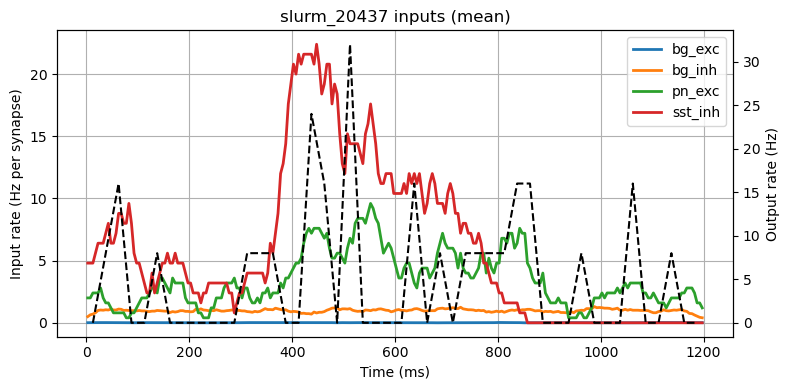

In [ ]:
run_input_analysis()

## 5. Simulation output
Spike raster + rate curve + spike-count stats.


Trials: 5
Spike count per trial: mean=6.20, std=1.72, min=4, max=9
Counts (first 10): [7.0, 5.0, 4.0, 9.0, 6.0]
Avg rate per trial (Hz): mean=5.17, std=1.43


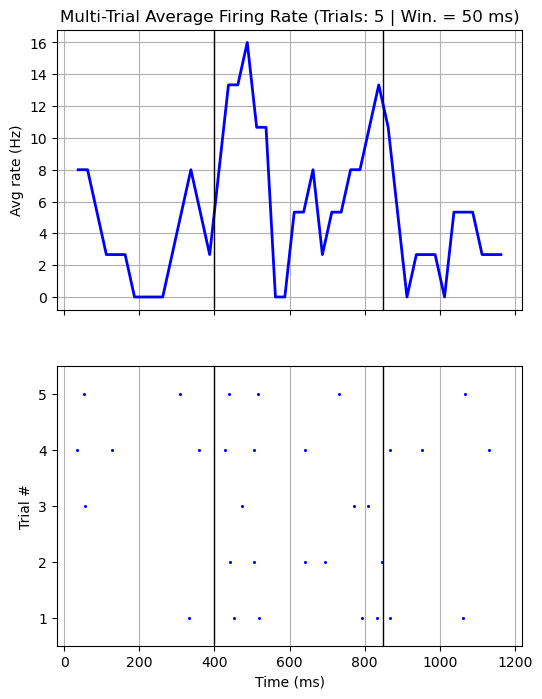

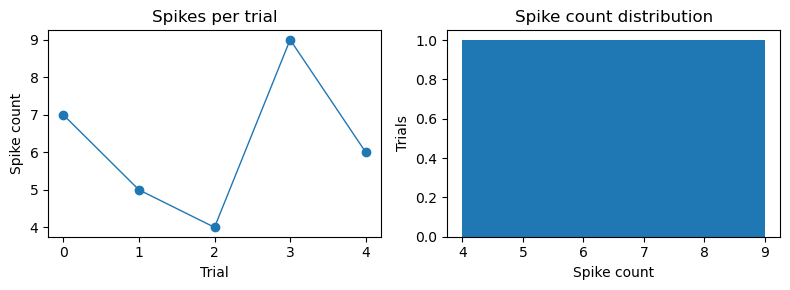

In [ ]:
run_output_analysis()

## 6. Comparison mode (optional)
Compare two runs side-by-side for outputs, inputs, and summaries.


In [ ]:
run_comparison_analysis()

Comparison disabled (set Compare B to a run name).


## IClamp Analysis (optional)

This section is separate from the main pipeline analysis and only runs when the selected run is an IClamp test.


In [ ]:
# IClamp-only analysis
from modules_local import run_sim

def _iclamp_stats(res):
    traces = res.get("traces", {}) or {}
    T = traces.get("T")
    V = traces.get("V")
    meta = res.get("meta", {}) or {}
    if T is None or V is None:
        return None
    delay = meta.get("delay_ms", None)
    dur = meta.get("dur_ms", None)
    if delay is not None:
        base_mask = T < float(delay)
        baseline = float(V[base_mask].mean()) if base_mask.any() else float(V.mean())
    else:
        baseline = float(V.mean())
    peak = float(V.max())
    vmin = float(V.min())
    spike_count = None
    spike_rate = None
    if delay is not None and dur is not None:
        start = float(delay)
        stop = float(delay + dur)
        seg = (T >= start) & (T <= stop)
        if seg.any():
            vseg = V[seg]
            crossings = ((vseg[:-1] < -20.0) & (vseg[1:] >= -20.0)).sum()
            spike_count = int(crossings)
            spike_rate = crossings / (dur / 1000.0) if dur > 0 else None
    return {
        "T": T,
        "V": V,
        "delay_ms": delay,
        "dur_ms": dur,
        "baseline": baseline,
        "peak": peak,
        "vmin": vmin,
        "spike_count": spike_count,
        "spike_rate": spike_rate,
    }

try:
    _ensure_single_loaded()
except Exception:
    resolve_runs()

res = res_single
mode = res.get("mode")
if mode != "iclamp":
    print(f"IClamp analysis skipped (mode={mode!r}). Select an iclamp run and re-run this cell.")
else:
    stats = _iclamp_stats(res)
    if stats is None:
        print("No trace data found for IClamp run.")
    else:
        print(f"Baseline Vm: {stats['baseline']:.2f} mV")
        print(f"Peak Vm: {stats['peak']:.2f} mV, Min Vm: {stats['vmin']:.2f} mV")
        if stats['spike_count'] is not None:
            print(f"Spike count during pulse: {stats['spike_count']} (rate {stats['spike_rate']:.2f} Hz)")
        plt.figure(figsize=(6, 4))
        plt.plot(stats['T'], stats['V'], lw=1.5)
        if stats['delay_ms'] is not None:
            plt.axvline(float(stats['delay_ms']), color='k', ls='--', lw=1)
        if stats['delay_ms'] is not None and stats['dur_ms'] is not None:
            plt.axvline(float(stats['delay_ms'] + stats['dur_ms']), color='k', ls='--', lw=1)
        plt.xlabel("Time (ms)")
        plt.ylabel("Vm (mV)")
        plt.title("IClamp Vm trace")
        plt.tight_layout()

        iclamp_payload = res.get("iclamp", {}) or {}
        currents = iclamp_payload.get("I")
        if isinstance(currents, dict) and currents:
            total_I = None
            for arr in currents.values():
                if total_I is None:
                    total_I = arr.copy()
                else:
                    total_I = total_I + arr
            if total_I is not None:
                plt.figure(figsize=(6, 3))
                plt.plot(stats['T'], total_I, lw=1.0)
                plt.xlabel("Time (ms)")
                plt.ylabel("Total membrane current")
                plt.title("Summed currents (if recorded)")
                plt.tight_layout()

# --- Compare two IClamp runs (A/B) ---
sel_local = _get_selection()
if sel_local.get("run_b") not in (None, "none", "None"):
    base_dir = sel_local['base']
    try:
        run_a = _resolve_run(base_dir, sel_local.get("run_a"))
        run_b = _resolve_run(base_dir, sel_local.get("run_b"))
        res_a = run_sim.load_results(run_a)
        res_b = run_sim.load_results(run_b)
    except Exception as exc:
        print(f"IClamp compare failed to load runs: {exc}")
    else:
        if res_a.get("mode") != "iclamp" or res_b.get("mode") != "iclamp":
            print("IClamp compare skipped: both runs must be mode='iclamp'.")
        else:
            stats_a = _iclamp_stats(res_a)
            stats_b = _iclamp_stats(res_b)
            if stats_a is None or stats_b is None:
                print("IClamp compare skipped: missing traces.")
            else:
                label_a = _run_label(run_a)
                label_b = _run_label(run_b)
                print(f"Compare A: {label_a}")
                print(f"  Baseline {stats_a['baseline']:.2f} mV, Peak {stats_a['peak']:.2f} mV, Min {stats_a['vmin']:.2f} mV")
                if stats_a['spike_count'] is not None:
                    print(f"  Spikes {stats_a['spike_count']} (rate {stats_a['spike_rate']:.2f} Hz)")
                print(f"Compare B: {label_b}")
                print(f"  Baseline {stats_b['baseline']:.2f} mV, Peak {stats_b['peak']:.2f} mV, Min {stats_b['vmin']:.2f} mV")
                if stats_b['spike_count'] is not None:
                    print(f"  Spikes {stats_b['spike_count']} (rate {stats_b['spike_rate']:.2f} Hz)")

                plt.figure(figsize=(6, 4))
                plt.plot(stats_a['T'], stats_a['V'], lw=1.5, label=label_a)
                plt.plot(stats_b['T'], stats_b['V'], lw=1.5, label=label_b)
                plt.xlabel("Time (ms)")
                plt.ylabel("Vm (mV)")
                plt.title("IClamp compare (Vm)")
                plt.legend()
                plt.tight_layout()


IClamp analysis skipped (mode='multi'). Select an iclamp run and re-run this cell.
